Diffusers and pipeline Code

In [1]:
from diffusers import StableDiffusion3Pipeline
import torch
from config import LAM_VALUES, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE

    # ── Load model once ───────────────────────────────────────────────────────────
pipe = StableDiffusion3Pipeline.from_pretrained(
	"stabilityai/stable-diffusion-3-medium-diffusers",
	torch_dtype=torch.float16,
	cache_dir=MODEL_CACHE,
)
pipe = pipe.to("cuda")
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Imports, configs

In [2]:
from pathlib import Path
import gc
import pandas as pd
from tqdm import tqdm
import shutil

TSR_DIR     = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/new_tsr_samples_tester")
PT_TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/new_pt_samples_tester")

REPLICA_EXCHANGE = True
LAM_VALUES = [1.15]
INDEX_UNTIL = 3

gc.collect()
torch.cuda.empty_cache()
    

In [3]:
if PT_TSR_DIR.exists():
    shutil.rmtree(PT_TSR_DIR)


Sample!

In [4]:
# ── Load prompts once ─────────────────────────────────────────────────────────
prompts = pd.read_csv(PROMPTS_FILE, usecols=["text"], nrows=INDEX_UNTIL)["text"].tolist()
print(f"Loaded {len(prompts)} prompts")


replica_exchanges = [True, False]

lam_dirs = {}
for re in replica_exchanges:
	base = PT_TSR_DIR if re else TSR_DIR
	lam_dirs[re] = {l: base / f"lam{l:.3f}".replace(".", "p") for l in LAM_VALUES}
	for d in lam_dirs[re].values():
		d.mkdir(parents=True, exist_ok=True)

# ── Sweep ─────────────────────────────────────────────────────────────────────
for idx, prompt in enumerate(prompts):
	
	for replica_exchange in replica_exchanges:
	
		for tsr_lam in tqdm(LAM_VALUES, desc=f"idx={idx} re={replica_exchange}"):

			output_dir = lam_dirs[replica_exchange][tsr_lam]

			if (output_dir / f"{idx:05d}.png").exists():
				continue

			generator = torch.Generator(device="cuda").manual_seed(SEED)

			images = pipe(
				prompt,
				negative_prompt="",
				num_inference_steps=N_INF_STEPS,
				guidance_scale=GUIDANCE_SCALE,
				tsr_lam=tsr_lam,
				tsr_sigma=TSR_SIGMA,
				replica_exchange=replica_exchange,
				swap_algorithm=SWAP_ALGORITHM,
				generator=generator,
			).images

			out_path = output_dir / f"{idx:05d}.png"
			images[0].save(out_path, icc_profile=None)


			del images
		torch.cuda.empty_cache()

print("\n All k values complete.")

Loaded 3 prompts


idx=0 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 1.15 with replica exchange True
 f between 1.150390625 and 2.587890625 mean 0.0179643165320158
 energy diff -0.11336296796798706 between lams s 2.587890625 and t 1.150390625 temp s 0.8730524778366089 t 0.986415445804596
Time 904.45 swap btwn source 2.59 and target 1.15 accept 0.998 std 0.901
 f between 1.150390625 and 2.587890625 mean 0.009420830756425858
 energy diff -0.1480366587638855 between lams s 2.587890625 and t 1.150390625 temp s 0.8333792686462402 t 0.9814159274101257
Time 887.74 swap btwn source 2.59 and target 1.15 accept 0.999 std 0.891
 f between 1.150390625 and 2.587890625 mean 0.028111722320318222
 energy diff -0.22299331426620483 between lams s 2.587890625 and t 1.150390625 temp s 0.745722234249115 t 0.9687155485153198
Time 851.33 swap btwn source 2.59 and target 1.15 accept 0.994 std 0.872
 f between 1.150390625 and 2.587890625 mean 0.019925378262996674
 energy diff -0.26088595390319824 between lams s 2.587890625 and t 1.150390625 temp s 0.7001301646232605 

idx=1 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 1.15 with replica exchange True
 f between 1.150390625 and 2.587890625 mean 0.014988502487540245
 energy diff -0.11336296796798706 between lams s 2.587890625 and t 1.150390625 temp s 0.8730524778366089 t 0.986415445804596
Time 904.45 swap btwn source 2.59 and target 1.15 accept 0.998 std 0.898
 f between 1.150390625 and 2.587890625 mean 0.007862608879804611
 energy diff -0.1480366587638855 between lams s 2.587890625 and t 1.150390625 temp s 0.8333792686462402 t 0.9814159274101257
Time 887.74 swap btwn source 2.59 and target 1.15 accept 0.999 std 0.887
 f between 1.150390625 and 2.587890625 mean 0.023719407618045807
 energy diff -0.22299331426620483 between lams s 2.587890625 and t 1.150390625 temp s 0.745722234249115 t 0.9687155485153198
Time 851.33 swap btwn source 2.59 and target 1.15 accept 0.995 std 0.864
 f between 1.150390625 and 2.587890625 mean 0.01666930317878723
 energy diff -0.26088595390319824 between lams s 2.587890625 and t 1.150390625 temp s 0.7001301646232605

idx=2 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 1.15 with replica exchange True
 f between 1.150390625 and 2.587890625 mean 0.008959177881479263
 energy diff -0.11336296796798706 between lams s 2.587890625 and t 1.150390625 temp s 0.8730524778366089 t 0.986415445804596
Time 904.45 swap btwn source 2.59 and target 1.15 accept 0.999 std 0.894
 f between 1.150390625 and 2.587890625 mean 0.004934775177389383
 energy diff -0.1480366587638855 between lams s 2.587890625 and t 1.150390625 temp s 0.8333792686462402 t 0.9814159274101257
Time 887.74 swap btwn source 2.59 and target 1.15 accept 0.999 std 0.879
 f between 1.150390625 and 2.587890625 mean 0.014974769204854965
 energy diff -0.22299331426620483 between lams s 2.587890625 and t 1.150390625 temp s 0.745722234249115 t 0.9687155485153198
Time 851.33 swap btwn source 2.59 and target 1.15 accept 0.997 std 0.850
 f between 1.150390625 and 2.587890625 mean 0.010653439909219742
 energy diff -0.26088595390319824 between lams s 2.587890625 and t 1.150390625 temp s 0.700130164623260

idx=2 re=False: 100%|██████████| 1/1 [00:00<00:00, 2255.00it/s]


 All k values complete.


Fid computation

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 1/1 [00:00<00:00,  1.47it/s]


Real features computed from 3 images.


── lam1p150 ──


CLIP lam=1.15: 100%|██████████| 3/3 [00:00<00:00, 20.35it/s]


[True]  lam=1.150  FID=256.0914  CLIP=30.7546


CLIP lam=1.15: 100%|██████████| 3/3 [00:00<00:00, 20.75it/s]


[False]  lam=1.150  FID=262.7582  CLIP=31.1592


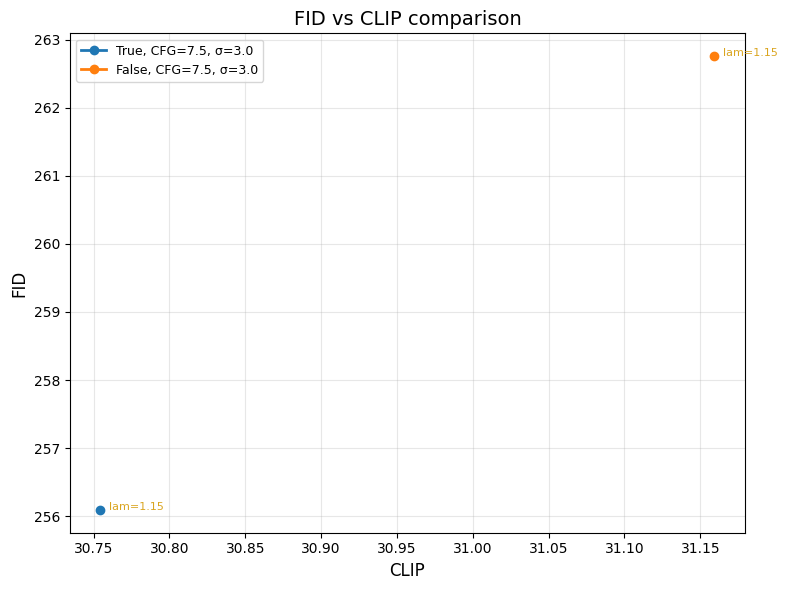

{True: {1.15: (np.float64(256.09140194879484),
   np.float64(30.754568099975586))},
 False: {1.15: (np.float64(262.75824283964687),
   np.float64(31.159245173136394))}}

In [5]:
from fid import compute_sweep
# from config import LAM_VALUES, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE


compute_sweep(
	lam_values=LAM_VALUES,
	replica_exchanges=[True, False],
	device="cuda",
	target_indices=None,
	index_until = INDEX_UNTIL,
	pt_sr_dir = PT_TSR_DIR,
	tsr_dir = TSR_DIR,
)